# Build DCLDE 2027 background windows

Builds background (non-event) windows from DCLDE 2027 recordings, for use as the
negative class alongside events from `annotations_w_calltype.csv`
(`build_dclde_2027_annotations.py`'s output).

Unlabeled time isn't automatically clean background -- it may contain unlabeled
calls, vessel noise, flow noise, or other transients. Steps, one per section below:
1. Slide a fixed-duration window across each annotated recording, discarding any
   window that overlaps a labeled event (+/- a buffer).
2. Prefilter survivors with a cheap RMS-energy / spectral-flatness stationarity
   score, dropping obvious transients before the expensive embedding step.
3. Embed the remaining candidates and the labeled events with a frozen encoder,
   then reject candidates that sit close to an event's embedding (probably an
   unlabeled call) or that are density outliers within the candidate pool itself
   (probably an unlabeled anomaly, not typical ambient noise).
4. Stratify the survivors by site, subsample to a target count, and enforce a
   minimum temporal gap between kept windows so the final set isn't
   autocorrelated (e.g. 500 consecutive windows from one calm afternoon).

Assumes `encoder_pipeline.embeddings.embed.PerchEmbeddingModel`: a frozen SurfPerch
encoder (see the README's "Representations" section -- 5s mel spectrograms, 0-16kHz)
implementing the same `EmbeddingModel` ABC as `HALLOEmbeddingModel`, i.e. it consumes
the same `(spec, label)`-batched `DataLoader`. Not yet implemented as of this writing --
the embedding cells below will raise `ImportError` until it lands.


In [90]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import DataLoader, Dataset

from encoder_pipeline.embeddings.embed import EmbeddingModel #, PerchEmbeddingModel
from encoder_pipeline.preprocessor.annotation import Annotation, AudioFile
from encoder_pipeline.preprocessor.config import AnnotationConfig, AudioFileConfig, MelConfig, SpectrogramConfig
from encoder_pipeline.preprocessor.spectrogram import Spectrogram

## Parameters

Edit these and re-run downstream cells.

In [91]:
PERCH_SAMPLE_RATE = 32_000  # SurfPerch's expected input sample rate (Nyquist = its 16kHz mel fmax)

annotations_path = Path("../data_raw/DCLDE_2027/annotations_w_calltype.csv")
out_path = Path("../data_raw/DCLDE_2027/background_windows.csv")

window_duration = 5.0  # candidate window length, seconds -- matches the event clip duration used downstream
hop_duration = 2.5  # stride between candidate window starts, seconds
event_buffer = 10.0  # seconds padded around each labeled event before excluding overlapping candidate windows
ambient_keep_fraction = 1.0  # fraction of candidates kept by the cheap stationarity prefilter
reject_closest_to_event_frac = 0.1  # fraction of candidates rejected for sitting nearest a labeled event's embedding
outlier_contamination = 0.05  # expected fraction of candidate-pool density outliers (IsolationForest)
min_keep_spacing = 30.0  # minimum seconds between two kept windows in the same recording
random_state = 0


## Load annotations

In [92]:
annotations = pd.read_csv(annotations_path, low_memory=False)
n_background_windows = 2 * len(annotations)  # target size of the final background set
annotations.head()

,Soundfile,Dataset,LowFreqHz,HighFreqHz,FileEndSec,UTC,FileBeginSec,ClassSpecies,KW,KW_certain,...,CallType,CalltypeCategory,HasQ,CalltypeHasQ,LocalPath,LocalFileOk,CenterTime,Duration,EcotypeCertain,Labels
0,DFOCRP.KkHK0R2F-NML1.SM2M-3.20131011_000600Z.flac,NorthBc,1062.50,1187.50,251.695,2013-10-11 00:10:11.439,251.439,AB,0,NaN,...,NaN,NaN,False,False,/data/DCLDE_2027/dclde_2027_killer_whales/dfo_...,True,251.567,0.256,False,AB
1,DFOCRP.KkHK0R2F-NML1.SM2M-3.20131011_000600Z.flac,NorthBc,1062.50,1187.50,268.256,2013-10-11 00:10:28,268.000,AB,0,NaN,...,NaN,NaN,False,False,/data/DCLDE_2027/dclde_2027_killer_whales/dfo_...,True,268.128,0.256,False,AB
2,DFOCRP.KkHK0R2F-NML1.SM2M-3.20131011_000600Z.flac,NorthBc,1093.75,1218.75,297.952,2013-10-11 00:10:57.6,297.600,AB,0,NaN,...,NaN,NaN,False,False,/data/DCLDE_2027/dclde_2027_killer_whales/dfo_...,True,297.776,0.352,False,AB
3,DFOCRP.KkHK0R2F-NML1.SM2M-3.20131011_002100Z.flac,NorthBc,1000.00,1218.75,26.624,2013-10-11 00:21:26.176,26.176,AB,0,NaN,...,NaN,NaN,False,False,/data/DCLDE_2027/dclde_2027_killer_whales/dfo_...,True,26.400,0.448,False,AB
4,DFOCRP.KkHK0R2F-NML1.SM2M-3.20131011_002100Z.flac,NorthBc,1062.50,1250.00,40.895,2013-10-11 00:21:40.639,40.639,AB,0,NaN,...,NaN,NaN,False,False,/data/DCLDE_2027/dclde_2027_killer_whales/dfo_...,True,40.767,0.256,False,AB


## 1. Select candidate background windows

Slide a window across every annotated recording, keeping only starts that don't
overlap a labeled event (+/- `event_buffer`).

In [93]:
def select_candidate_windows(annotations: pd.DataFrame, window_duration: float, hop_duration: float, event_buffer: float) -> pd.DataFrame:
    """Slides a window across every annotated recording, keeping only starts
    that don't overlap a labeled event (+/- event_buffer)."""
    valid = annotations[annotations["LocalFileOk"]].copy()

    candidates = []
    for local_path, file_rows in valid.groupby("LocalPath"):
        file_duration = librosa.get_duration(path=local_path)
        padded = list(zip(file_rows["FileBeginSec"] - event_buffer, file_rows["FileEndSec"] + event_buffer))

        for start in np.arange(0, file_duration - window_duration, hop_duration):
            end = start + window_duration
            if any(start < pe and end > ps for ps, pe in padded):
                continue
            candidates.append({
                "Soundfile": file_rows["Soundfile"].iloc[0],
                "LocalPath": local_path,
                "Dataset": file_rows["Dataset"].iloc[0] if "Dataset" in file_rows else None,
                "FileBeginSec": float(start),
                "FileEndSec": float(end),
            })
    return pd.DataFrame(candidates)


In [94]:
candidates = select_candidate_windows(annotations, window_duration, hop_duration, event_buffer)
print(f"{len(candidates):,} raw candidate windows")
candidates.head()

/tmp/ipykernel_3689247/1760714182.py:8: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  file_duration = librosa.get_duration(path=local_path)


972,678 raw candidate windows


,Soundfile,LocalPath,Dataset,FileBeginSec,FileEndSec
0,DFOCRP.KkHK0R2F-NML1.SM2M-3.20131011_000600Z.flac,/data/DCLDE_2027/dclde_2027_killer_whales/dfo_...,NorthBc,0.0,5.0
1,DFOCRP.KkHK0R2F-NML1.SM2M-3.20131011_000600Z.flac,/data/DCLDE_2027/dclde_2027_killer_whales/dfo_...,NorthBc,2.5,7.5
2,DFOCRP.KkHK0R2F-NML1.SM2M-3.20131011_000600Z.flac,/data/DCLDE_2027/dclde_2027_killer_whales/dfo_...,NorthBc,5.0,10.0
3,DFOCRP.KkHK0R2F-NML1.SM2M-3.20131011_000600Z.flac,/data/DCLDE_2027/dclde_2027_killer_whales/dfo_...,NorthBc,7.5,12.5
4,DFOCRP.KkHK0R2F-NML1.SM2M-3.20131011_000600Z.flac,/data/DCLDE_2027/dclde_2027_killer_whales/dfo_...,NorthBc,10.0,15.0


## 2. Ambient prefilter

Cheap spectral-flatness score, used to drop obvious non-ambient candidates
before the expensive embedding step. Tonal signals (calls) skew toward low
flatness; broadband, noise-like ambient background skews toward high
flatness -- so mean flatness across a window is a decent proxy for "does this
sound like typical ambient noise."


In [95]:
def ambient_score(clip: np.ndarray) -> float:
    """Higher = more likely to be ambient background noise (keep-worthy).
    Mean spectral flatness across the clip's STFT frames -- tonal signals
    (calls) skew low, broadband/noise-like ambient background skews high."""
    S = np.abs(librosa.stft(clip))
    flatness = librosa.feature.spectral_flatness(S=S)[0]
    return flatness.mean()


def ambient_prefilter(candidates: pd.DataFrame, ambient_keep_fraction: float) -> pd.DataFrame:
    """Keeps the ambient_keep_fraction candidates with the highest ambient_score.
    Loads each file at its own native sample rate (AudioFile's default) rather
    than a fixed target -- resampling a low-native-rate file up to a shared
    target would fabricate a silent upper half of the spectrum that was never
    really recorded, biasing the score against/for whichever equipment a site
    happened to use."""
    candidates = candidates.sort_values("LocalPath").reset_index(drop=True)
    scores = np.empty(len(candidates))
    for local_path, group in candidates.groupby("LocalPath"):
        audio_file = AudioFile(local_path)
        for idx, row in group.iterrows():
            clip = audio_file.slice(row["FileBeginSec"], row["FileEndSec"] - row["FileBeginSec"])
            scores[idx] = ambient_score(clip)
    candidates["ambient_score"] = scores
    n_keep = max(1, round(len(candidates) * ambient_keep_fraction))
    return candidates.nlargest(n_keep, "ambient_score").reset_index(drop=True)


### Sanity check: a real call vs. a candidate window

Before running the prefilter over the whole pool, look at what it's actually
scoring: an SRKW call's spectrogram + spectral flatness against a candidate
background window's.

In [96]:
def plot_spectrogram_and_flatness(ax_spec, ax_flat, clip: np.ndarray, sr: int, title: str) -> None:
    """Plots a clip's dB spectrogram and its spectral flatness -- both derived
    from the same STFT magnitude -- labeled with its ambient_score."""
    S = np.abs(librosa.stft(clip))
    score = ambient_score(clip)

    stft_db = librosa.amplitude_to_db(S, ref=np.max)
    librosa.display.specshow(stft_db, sr=sr, x_axis="time", y_axis="hz", ax=ax_spec)
    ax_spec.set_title(title)

    flatness = librosa.feature.spectral_flatness(S=S)[0]
    times = librosa.frames_to_time(np.arange(len(flatness)), sr=sr)
    ax_flat.plot(times, flatness)
    ax_flat.set_ylim(0, 1)
    ax_flat.set_xlabel("time (s)")
    ax_flat.set_ylabel("spectral flatness")
    ax_flat.set_title(f"ambient_score = {score:.3f}")


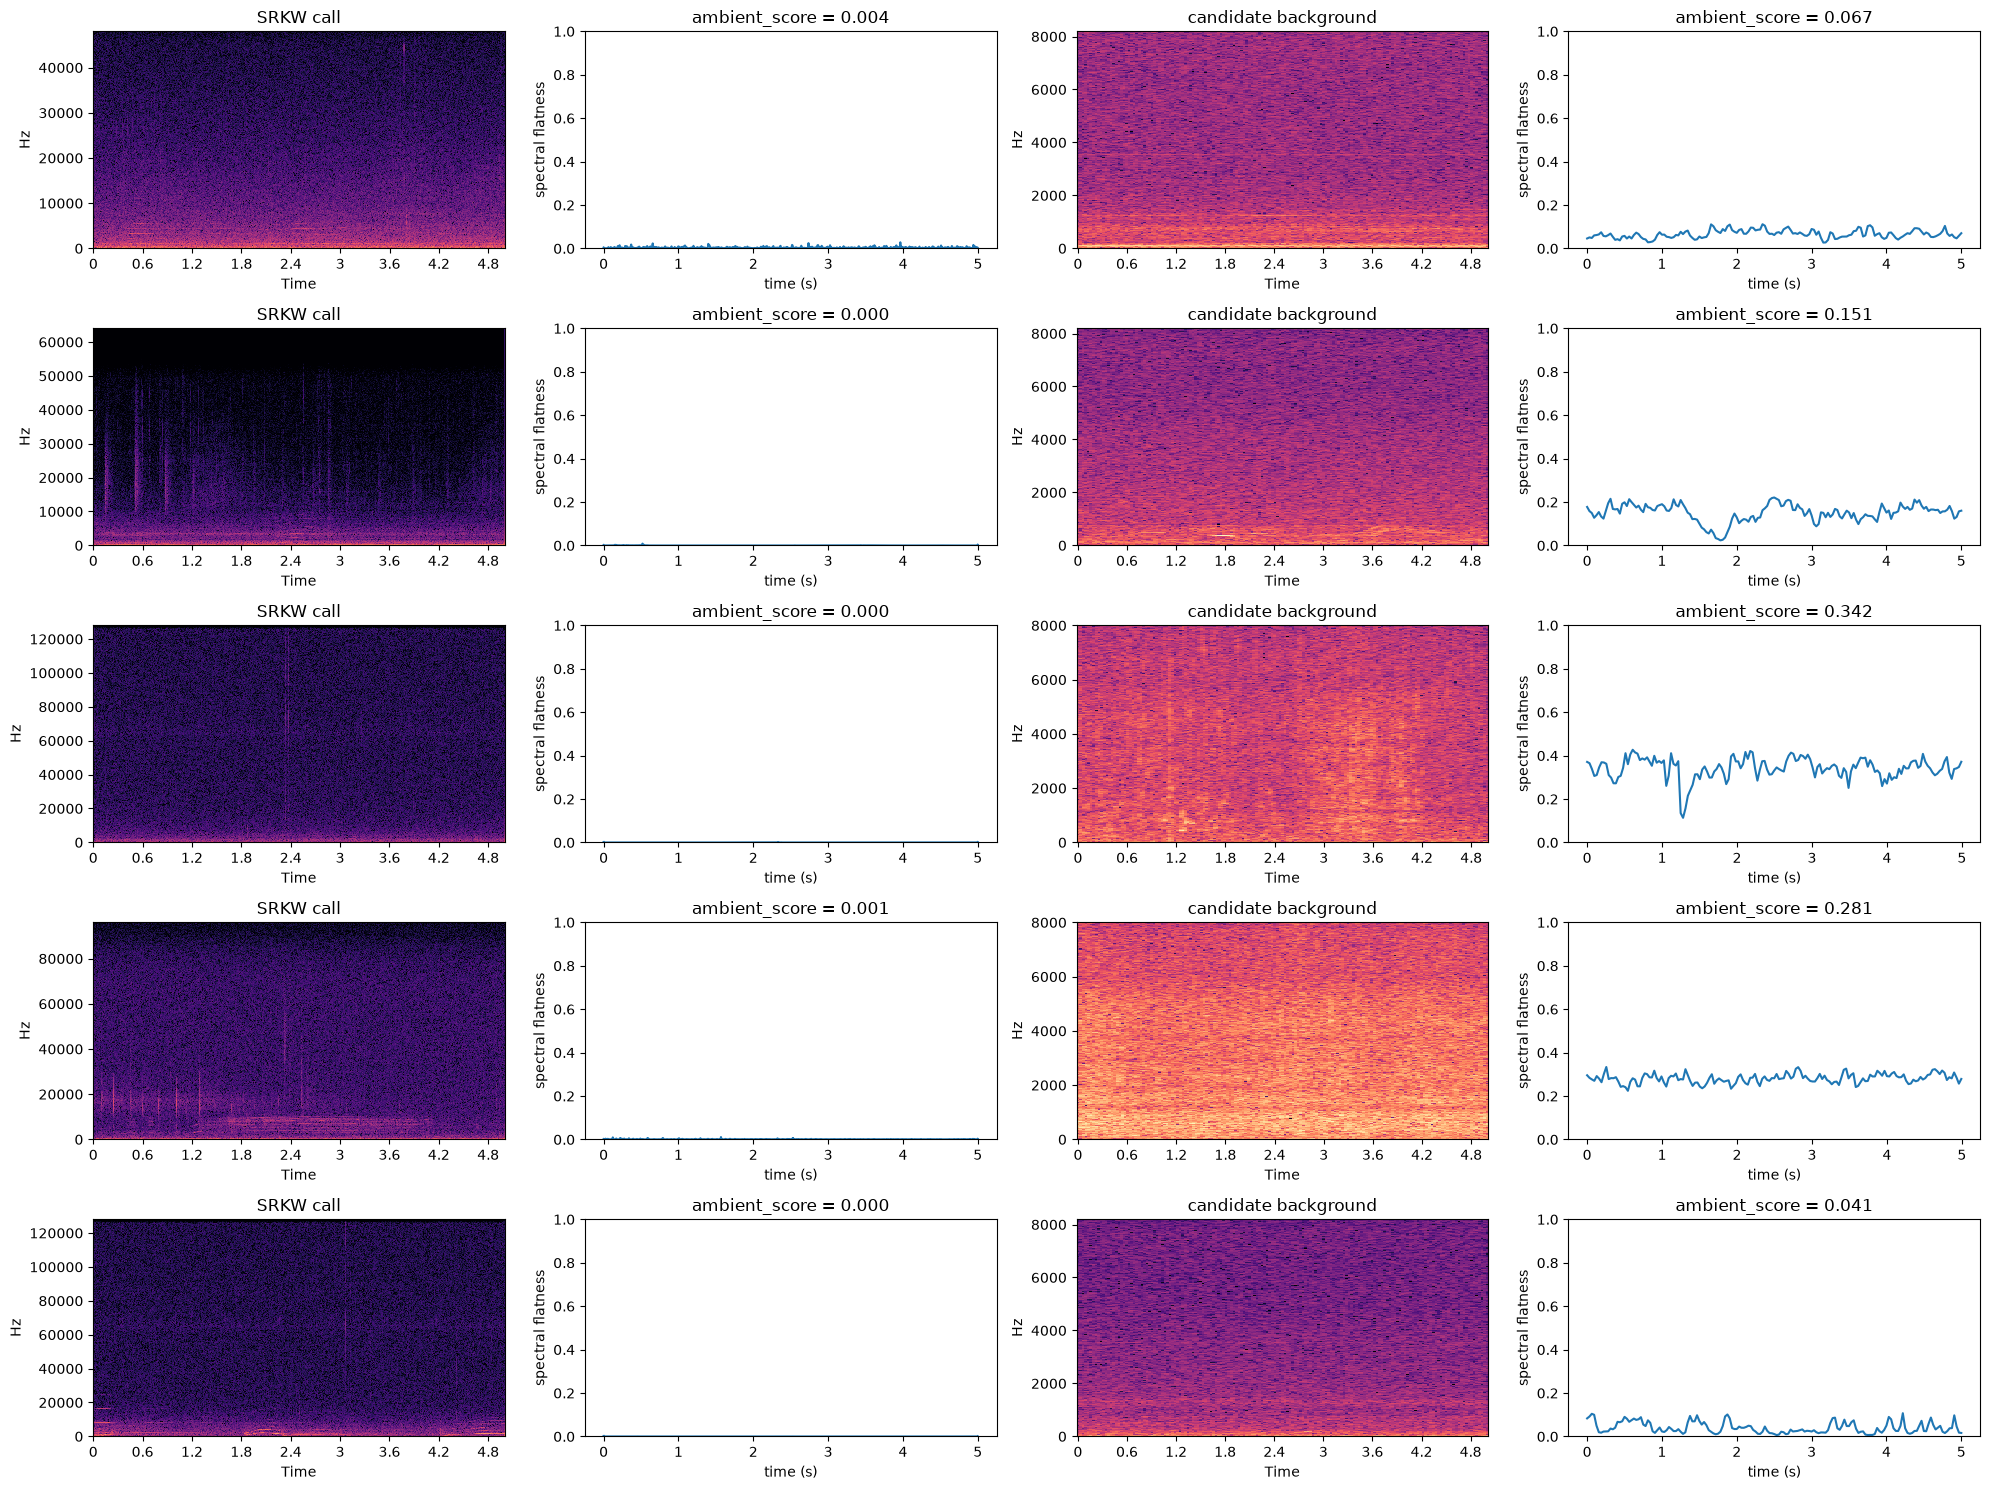

In [97]:
n_samples = 5
srkw_rows = annotations[annotations["Labels"] == "SRKW"].sample(n=n_samples, random_state=random_state)
candidate_rows = candidates.sample(n=n_samples, random_state=random_state)

fig, axes = plt.subplots(n_samples, 4, figsize=(20, 3 * n_samples))
for i, ((_, srkw_row), (_, candidate_row)) in enumerate(zip(srkw_rows.iterrows(), candidate_rows.iterrows())):
    srkw_audio = AudioFile(srkw_row["LocalPath"])  # native sample rate, not PERCH_SAMPLE_RATE
    srkw_clip = srkw_audio.slice(srkw_row["CenterTime"] - window_duration / 2, window_duration)

    candidate_audio = AudioFile(candidate_row["LocalPath"])
    candidate_clip = candidate_audio.slice(
        candidate_row["FileBeginSec"], candidate_row["FileEndSec"] - candidate_row["FileBeginSec"],
    )

    plot_spectrogram_and_flatness(axes[i, 0], axes[i, 1], srkw_clip, srkw_audio.sr, "SRKW call")
    plot_spectrogram_and_flatness(axes[i, 2], axes[i, 3], candidate_clip, candidate_audio.sr, "candidate background")
fig.tight_layout()


### Mean ambient_score by annotation class

Extends the 5-sample eyeball check to every label in the annotations set: sample a handful of windows per class, score them, and compare means -- background should score highest, tonal call types should score lowest.

In [98]:
def sample_by_label(annotations: pd.DataFrame, window_duration: float, n_samples: int, random_state: int) -> pd.DataFrame:
    """Samples up to n_samples valid rows per Labels value, windowed to
    window_duration around each row's CenterTime."""
    valid = annotations[annotations["LocalFileOk"]].copy()
    valid["FileBeginSec"] = valid["CenterTime"] - window_duration / 2
    valid["FileEndSec"] = valid["CenterTime"] + window_duration / 2
    samples = [group.sample(n=min(n_samples, len(group)), random_state=random_state) for _, group in valid.groupby("Labels")]
    return pd.concat(samples, ignore_index=True)


def score_by_label(annotations: pd.DataFrame, window_duration: float, n_samples: int = 50, random_state: int = 0) -> pd.DataFrame:
    """Samples up to n_samples rows per Labels value and scores each with
    ambient_score, to compare how the score distributes across annotated classes.
    Skips files librosa can't decode -- the real corpus has a handful of corrupt
    audio files."""
    sampled = sample_by_label(annotations, window_duration, n_samples, random_state)
    sampled = sampled.sort_values("LocalPath").reset_index(drop=True)

    scores = np.full(len(sampled), np.nan)
    n_skipped = 0
    for local_path, group in sampled.groupby("LocalPath"):
        try:
            audio_file = AudioFile(local_path)
        except Exception:
            n_skipped += len(group)
            continue
        for idx, row in group.iterrows():
            clip = audio_file.slice(row["FileBeginSec"], row["FileEndSec"] - row["FileBeginSec"])
            scores[idx] = ambient_score(clip)
    if n_skipped:
        print(f"skipped {n_skipped} rows: file couldn't be decoded")
    sampled["ambient_score"] = scores
    return sampled.dropna(subset=["ambient_score"])


In [99]:
label_scores = score_by_label(annotations, window_duration, n_samples=50, random_state=random_state)
label_scores.groupby("Labels")["ambient_score"].agg(["mean", "std", "count"])


/home/noah/perch_venv/lib/python3.11/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(
/home/noah/HALLO_encoder_collection/src/encoder_pipeline/preprocessor/annotation.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  self.audio, self.sr = librosa.load(file_path, sr=resample_sr)
/home/noah/perch_venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


,mean,std,count
Labels,,,
AB,0.220367,0.281633,50
HW,0.127512,0.146575,50
KW_und,0.017699,0.038481,50
NRKW,0.212284,0.107863,50
OKW,0.087476,0.159392,50
SAR,0.040757,0.064043,50
SRKW,0.019269,0.052508,50
TKW,0.088714,0.101748,50
UndBio,0.194537,0.102813,50


In [89]:
candidates = ambient_prefilter(candidates.iloc[:100], ambient_keep_fraction)
print(f"{len(candidates):,} candidates after ambient prefilter")
candidates['ambient_score'].describe()

100 candidates after ambient prefilter


count    100.000000
mean       0.086831
std        0.035434
min        0.026088
25%        0.062054
50%        0.079068
75%        0.106337
max        0.180781
Name: ambient_score, dtype: float64

## 3. Embedding-based novelty filter

Embed candidates and labeled events with a frozen encoder, then reject
candidates that are (a) close to a known event's embedding -- probably an
unlabeled instance of a known call type -- or (b) density outliers within the
candidate pool itself -- probably an unlabeled anomaly, not typical ambient.

`WindowSpectrogramDataset` is the one class here: torch's `Dataset` API requires
subclassing, everything else in this notebook is a plain function.

In [ ]:
class WindowSpectrogramDataset(Dataset):
    """Computes a mel spectrogram on the fly for each (file, start) window, reusing
    the same Annotation/Spectrogram classes run_preprocessor uses to build training
    data -- keeps embedding inputs identical in shape/format to what the trained
    pipeline sees.

    Assumes `windows` is already sorted by LocalPath: only the most recently opened
    file's decoded audio is kept in memory."""

    def __init__(self, windows: pd.DataFrame, window_duration: float, spec_config: SpectrogramConfig, audio_file_config: AudioFileConfig) -> None:
        self.windows = windows.reset_index(drop=True)
        self.annotation_config = AnnotationConfig(time_offset=window_duration / 2)
        self.spectrogram = Spectrogram(spec_config)
        self.audio_file_config = audio_file_config
        self._cached_path = None
        self._cached_audio_file = None

    def _audio_file(self, path: str) -> AudioFile:
        if path != self._cached_path:
            self._cached_audio_file = AudioFile(path, self.audio_file_config.resample_sr)
            self._cached_path = path
        return self._cached_audio_file

    def __len__(self) -> int:
        return len(self.windows)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        row = self.windows.iloc[idx]
        audio_file = self._audio_file(row["LocalPath"])
        annotation = Annotation(audio_file, "unlabeled", row["FileBeginSec"], row["FileEndSec"] - row["FileBeginSec"], self.annotation_config)
        raw = self.spectrogram.compute_mel(annotation)
        return torch.from_numpy(self.spectrogram.apply_dynamic(annotation, raw)).float(), idx


def build_event_windows(annotations: pd.DataFrame, window_duration: float) -> pd.DataFrame:
    """Fixed window_duration windows centered on every labeled event, for the
    novelty filter's known-call-type comparison."""
    events = annotations[(annotations["Labels"] != "Background") & annotations["LocalFileOk"]].copy()
    events["FileBeginSec"] = events["CenterTime"] - window_duration / 2
    events["FileEndSec"] = events["CenterTime"] + window_duration / 2
    return events


def embed_windows(
    windows: pd.DataFrame, window_duration: float, spec_config: SpectrogramConfig, audio_file_config: AudioFileConfig,
    model: EmbeddingModel, batch_size: int = 32,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Returns (windows sorted by LocalPath, their embeddings in that same order)."""
    windows = windows.sort_values("LocalPath").reset_index(drop=True)
    dataset = WindowSpectrogramDataset(windows, window_duration, spec_config, audio_file_config)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    embeddings, _ = model.extract(loader)
    return windows, embeddings


def novelty_filter(
    candidates: pd.DataFrame, candidate_emb: np.ndarray, event_emb: np.ndarray,
    reject_closest_to_event_frac: float, outlier_contamination: float, random_state: int = 0,
) -> pd.DataFrame:
    """Rejects candidates that are (a) close to a known event's embedding, or (b)
    density outliers within the candidate pool itself."""
    event_dist = NearestNeighbors(n_neighbors=1).fit(event_emb).kneighbors(candidate_emb)[0][:, 0]
    too_close_to_event = event_dist <= np.quantile(event_dist, reject_closest_to_event_frac)

    is_outlier = IsolationForest(
        contamination=outlier_contamination, random_state=random_state,
    ).fit_predict(candidate_emb) == -1

    keep = ~too_close_to_event & ~is_outlier
    print(f"novelty filter: dropped {too_close_to_event.sum()} too-close-to-event, {is_outlier.sum()} density outliers, {keep.sum()} kept")
    result = candidates.loc[keep].copy()
    result["event_embedding_distance"] = event_dist[keep]
    return result

In [ ]:
spec_config = SpectrogramConfig(freq_scale="mel", mel=MelConfig(fmax=PERCH_SAMPLE_RATE / 2))
audio_file_config = AudioFileConfig(resample_sr=PERCH_SAMPLE_RATE)
model = PerchEmbeddingModel()

In [ ]:
event_windows = build_event_windows(annotations, window_duration)
candidates, candidate_emb = embed_windows(candidates, window_duration, spec_config, audio_file_config, model)
_, event_emb = embed_windows(event_windows, window_duration, spec_config, audio_file_config, model)
print(f"{len(candidates):,} candidate embeddings, {len(event_emb):,} event embeddings, dim={candidate_emb.shape[1]}")

In [ ]:
candidates = novelty_filter(candidates, candidate_emb, event_emb, reject_closest_to_event_frac, outlier_contamination, random_state)
candidates.head()

## 4. Stratify, balance, and de-dup

Stratify by site so the kept set reflects real ambient diversity across
deployments (not just the quietest clips), enforce a minimum temporal gap
between kept windows in the same recording, then subsample to the target
count.


In [ ]:
def strata(windows: pd.DataFrame) -> pd.Series:
    return windows["Dataset"].fillna("unknown").astype(str)


def dedupe_temporal(windows: pd.DataFrame, min_keep_spacing: float) -> pd.DataFrame:
    """Drops candidates within min_keep_spacing seconds of the previous kept
    window in the same recording -- avoids autocorrelated runs (e.g. 500
    consecutive windows from one calm afternoon)."""
    keep_idx = []
    for _, group in windows.sort_values("FileBeginSec").groupby("LocalPath"):
        last_kept_end = -np.inf
        for idx, row in group.iterrows():
            if row["FileBeginSec"] - last_kept_end >= min_keep_spacing:
                keep_idx.append(idx)
                last_kept_end = row["FileBeginSec"]
    return windows.loc[keep_idx]


def sample_background(windows: pd.DataFrame, n_target: int, random_state: int = 0) -> pd.DataFrame:
    """Stratifies by site, then subsamples to n_target."""
    n_target = min(n_target, len(windows))
    strata_labels = strata(windows)
    sampled = (
        windows.assign(_stratum=strata_labels)
        .groupby("_stratum", group_keys=False)
        .apply(
            lambda g: g.sample(n=max(1, round(n_target * len(g) / len(windows))), random_state=random_state),
            include_groups=False,
        )
    )
    return sampled.sample(n=min(n_target, len(sampled)), random_state=random_state).reset_index(drop=True)


In [ ]:
deduped = dedupe_temporal(candidates, min_keep_spacing)
print(f"{len(deduped):,} candidates after temporal de-dup")

background = sample_background(deduped, n_background_windows, random_state)
background["Labels"] = "Background"
print(f"{len(background):,} final background windows")
background.head()


## Save

In [ ]:
out_path.parent.mkdir(parents=True, exist_ok=True)
background.to_csv(out_path, index=False)
print(f"Saved {len(background):,} background windows -> {out_path}")